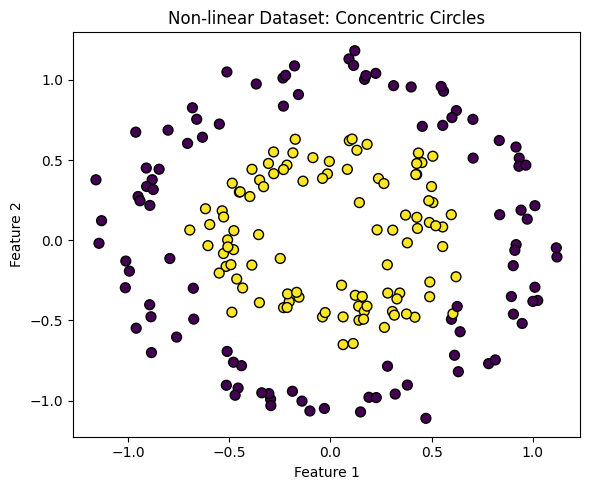

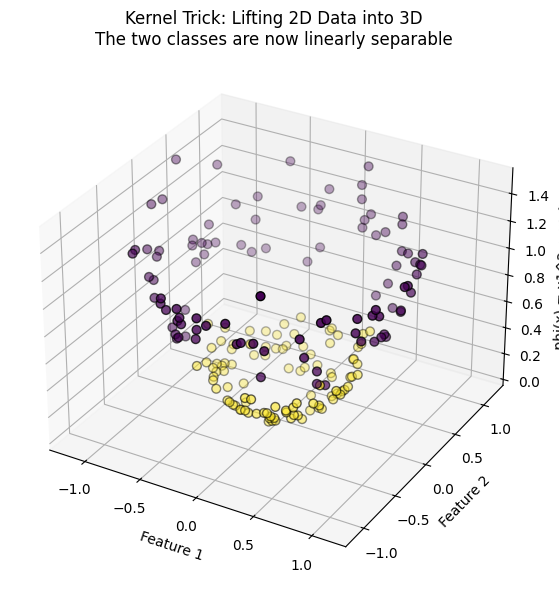

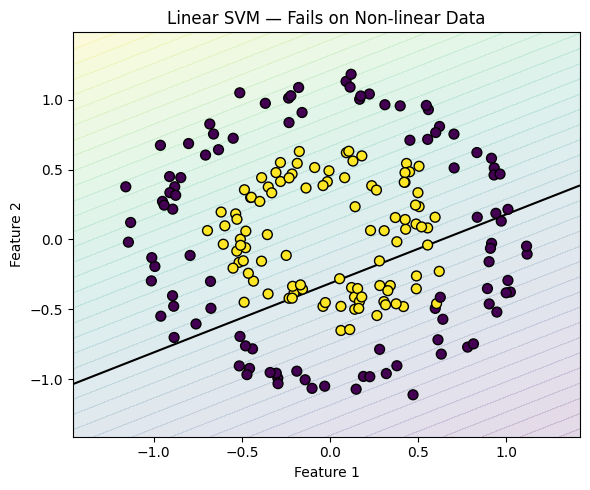

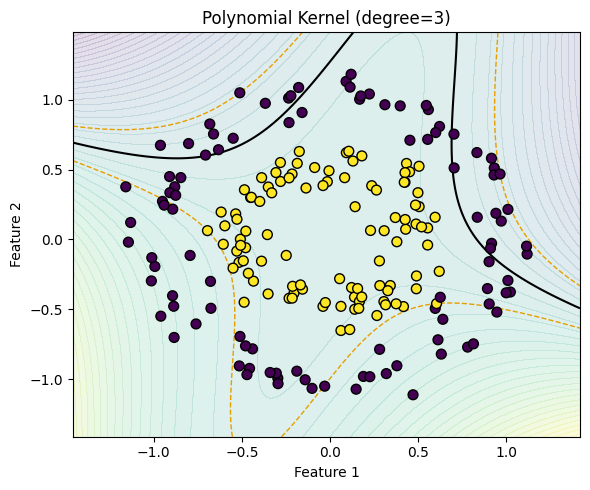

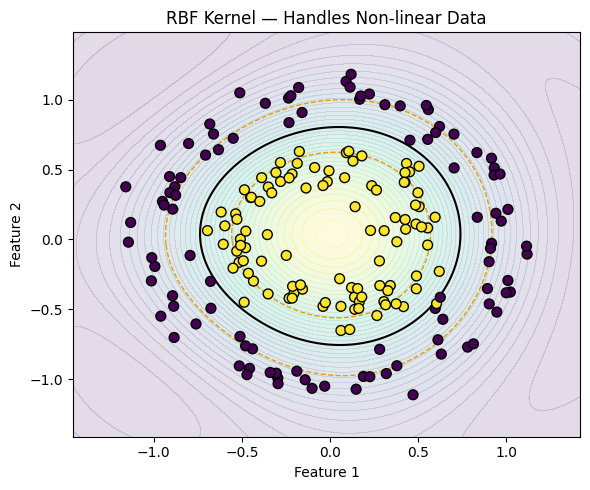

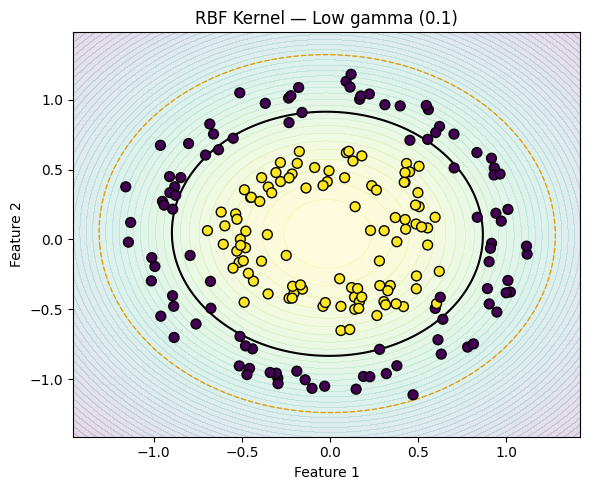

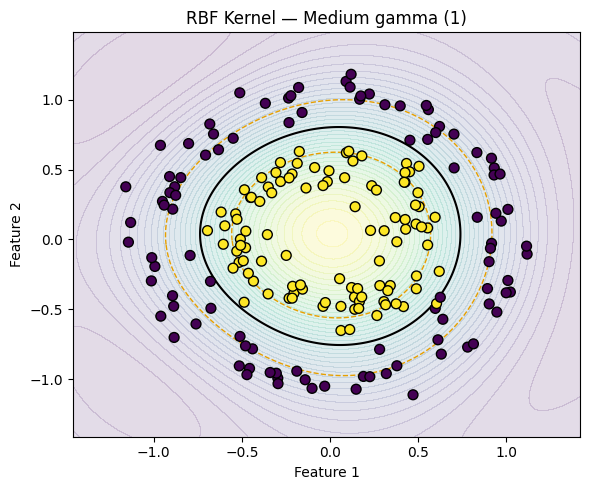

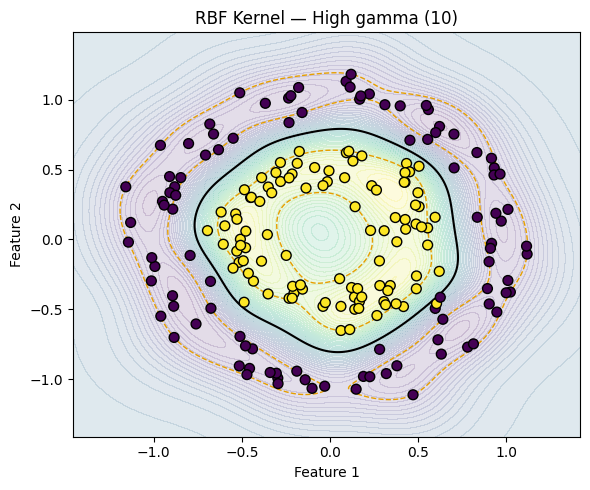

In [3]:
# ==============================
# SVM Kernel Trick - Tutorial
# ==============================

# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn import svm
from sklearn.datasets import make_circles

# 1. Generate the Dataset

X, y = make_circles(n_samples=200, factor=0.5, noise=0.1, random_state=42)

# 2. Visualise the Raw Dataset

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k', s=50)
plt.title("Non-linear Dataset: Concentric Circles")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()

# 3. Kernel Trick: 3D Projection
#    We create a new feature: phi(x) = x1^2 + x2^2
#    This "lifts" the 2D data into 3D space,
#    where the two classes become separable
#    by a flat hyperplane — the core idea behind
#    the kernel trick.

Z_lift = X[:, 0]**2 + X[:, 1]**2
 
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], Z_lift, c=y, cmap='viridis', edgecolors='k', s=40)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("phi(x) = x1^2 + x2^2")
ax.set_title("Kernel Trick: Lifting 2D Data into 3D\n"
             "The two classes are now linearly separable")
plt.tight_layout()
plt.show()

# 4. Plotting Helper: Decision Boundary
#    Draws the decision boundary (solid line)
#    and the margins (dashed lines).

def plot_decision_boundary(model, X, y, title):
    model.fit(X, y)
 
    fig, ax = plt.subplots(figsize=(6, 5))
 
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k', s=50, zorder=3)
 
    # Build a grid across the data range
    x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
    y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
    xx = np.linspace(x_min, x_max, 300)
    yy = np.linspace(y_min, y_max, 300)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
 
    # Shade background by decision region
    Z = model.decision_function(xy).reshape(XX.shape)
    ax.contourf(XX, YY, Z, levels=50, cmap='viridis', alpha=0.15)
 
    ax.contour(XX, YY, Z, levels=[-1, 0, 1],
               linestyles=['--', '-', '--'],
               colors=['#E69F00', 'black', '#E69F00'],
               linewidths=[1, 1.5, 1])
 
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    plt.tight_layout()
    plt.show()

# 5. Compare Kernels

# Linear — straight-line boundary, cannot separate circles
plot_decision_boundary(
    svm.SVC(kernel='linear'),
    X, y,
    "Linear SVM — Fails on Non-linear Data"
)

# Polynomial (degree 3) — curved boundary
plot_decision_boundary(
    svm.SVC(kernel='poly', degree=3),
    X, y,
    "Polynomial Kernel (degree=3)"
)

# RBF — flexible, radial boundary
plot_decision_boundary(
    svm.SVC(kernel='rbf', gamma=1),
    X, y,
    "RBF Kernel — Handles Non-linear Data"
)

# 6. Effect of gamma on the RBF Kernel
#    gamma controls how 'local' each point's
#    influence is on the decision boundary.
#
#    Small gamma  -> smooth, wide boundary
#    Medium gamma -> balanced (good fit)
#    Large gamma  -> very tight, may overfit

gamma_settings = [
    (0.1, "RBF Kernel — Low gamma (0.1)"),
    (1,   "RBF Kernel — Medium gamma (1)"),
    (10,  "RBF Kernel — High gamma (10)"),
]

for g, title in gamma_settings:
    plot_decision_boundary(
        svm.SVC(kernel='rbf', gamma=g),
        X, y,
        title
    )